In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import unicodedata
from sklearn.model_selection import train_test_split


In [ ]:
def normalize_phoneme(p):
    p = p.strip()
    p = unicodedata.normalize("NFC", p)

    # remove zero-width chars
    p = p.replace("\u200c", "").replace("\u200d", "")
    word = word.replace("-", "")



    return p

In [ ]:
DEVANAGARI_MATRAS = {
    "ा": "आ", "ि": "इ", "ी": "ई", "ु": "उ", "ू": "ऊ",
    "ृ": "ऋ", "ॄ": "ॠ", "ॢ": "ऌ", "ॣ": "ॡ",
    "े": "ए", "ै": "ऐ", "ो": "ओ", "ौ": "औ",
}

# independent vowels set
DEVANAGARI_VOWELS = set(list("अआइईउऊऋॠऌॡएऐओऔ"))

# consonants range roughly (क..ह) — we'll treat these as consonants
# include nukta & other combining marks handled separately
DEVANAGARI_CONSONANTS = set(list(
    "कखगघङचछजझञटठडढणतथदधनपफबभमयऱलवशषसह"
))
# add retroflex/rule variants if needed (adjust per data)
# Halant, nukta, anusvara, visarga
HALANT = "\u094D"     # ्
NUKTA = "\u093C"      # ़
ANUSVARA = "ं"
VISARGA = "ः"
CANDRABINDU = "ँ"

PHONETIC_MODIFIERS = {ANUSVARA, VISARGA, CANDRABINDU}

def akshara_to_phonemes(token):

    token = unicodedata.normalize("NFC", token.strip())
    phonemes = []
    i = 0
    chars = list(token)

    while i < len(chars):
        ch = chars[i]

        # independent vowel
        if ch in DEVANAGARI_VOWELS:
            phonemes.append(ch)
            i += 1
            continue

        # modifier symbols that act like separate phonemes (anusvara/visarga)
        if ch in PHONETIC_MODIFIERS:
            phonemes.append(ch)
            i += 1
            continue

        # consonant (including possible nukta immediately after)
        if ch in DEVANAGARI_CONSONANTS:
            base = ch
            i += 1
            # nukta (rare) e.g. क़
            if i < len(chars) and chars[i] == NUKTA:
                base = base + chars[i]
                i += 1

            # halant means explicit consonant without inherent vowel
            if i < len(chars) and chars[i] == HALANT:
                # append base (consonant) only, skip halant
                phonemes.append(base)
                i += 1
                continue

            # vowel matra attached? map to independent vowel and append base+vowel
            if i < len(chars) and chars[i] in DEVANAGARI_MATRAS:
                mat = chars[i]
                vowel = DEVANAGARI_MATRAS[mat]
                phonemes.append(base)
                phonemes.append(vowel)
                i += 1
                continue

            # If no matra/halant follows, append consonant (in many phonemic analyses
            # the inherent vowel 'अ' is present. Depending on your phoneme vectors you
            # may want to append 'अ' as well. Here we append the consonant alone,
            # which matches a common phoneme mapping where consonant segments are separate.)
            phonemes.append(base)
            continue

        # standalone matra (shouldn't usually happen), convert to vowel
        if ch in DEVANAGARI_MATRAS:
            phonemes.append(DEVANAGARI_MATRAS[ch])
            i += 1
            continue

        # otherwise: unknown char, append as-is (fallback)
        phonemes.append(ch)
        i += 1

    return phonemes


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
## Loading Phonetic Characters Vectors

def load_phone_vectors(csv_path):
    df = pd.read_csv("/content/drive/MyDrive/Sanskrit NLP/sanskrit_phoneme_vectors (1).csv")

    phoneme_col = df.columns[0]
    feature_cols = df.columns[1:]

    df[feature_cols] = (
        df[feature_cols]
        .astype(str)
        .replace("−", "-", regex=True)
        .replace(r"^\s*$", "0", regex=True)
    )

    df[feature_cols] = df[feature_cols].apply(
        lambda col: pd.to_numeric(col, errors="coerce")
    ).fillna(0.0)

    def to_ternary(x):
        if x > 0:
            return 1.0
        elif x < 0:
            return -1.0
        else:
            return 0.0

    df[feature_cols] = df[feature_cols].applymap(to_ternary)

    feature_matrix = df[feature_cols].to_numpy(dtype=np.float32)

    unique_vals = set(np.unique(feature_matrix))
    assert unique_vals.issubset({-1.0, 0.0, 1.0}), \
        f"Non-ternary values found: {unique_vals}"

    phoneme_to_vec = {}
    for i, phoneme in enumerate(df[phoneme_col]):
        phoneme = str(phoneme).strip()
        phoneme_to_vec[phoneme] = torch.from_numpy(feature_matrix[i])

    panphon_dim = feature_matrix.shape[1]
    return phoneme_to_vec, panphon_dim


In [ ]:

phoneme_to_vec, dim = load_phone_vectors("/content/drive/MyDrive/Sanskrit NLP/sanskrit_phoneme_vectors (1).csv")

v = phoneme_to_vec[list(phoneme_to_vec.keys())[21]]
print(v)
print(torch.unique(v))


tensor([-1., -1., -1.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.])
tensor([-1.,  0.,  1.])


/tmp/ipykernel_5258/2685310092.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[feature_cols] = df[feature_cols].applymap(to_ternary)


In [ ]:
def load_triplets(csv_path):
    df = pd.read_excel(csv_path)

    triplets = []
    for _, row in df.iterrows():
        triplets.append({
            "anchor": row["anchor"].split(),
            "positive": row["positive"].split(),
            "negative": row["negative"].split()
        })
    return triplets
    type(triplets)
    type(triplets[0])
    type(triplets[0]["anchor"])
    type(triplets[0]["anchor"][0])

triplets = load_triplets("/content/drive/MyDrive/Sanskrit NLP/sridath_system_panphon_triplets_3.xlsx")

for i in range(3):
    print(triplets[i])

{'anchor': ['दातॄन्'], 'positive': ['दूतान्'], 'negative': ['शृ॒णु॒']}
{'anchor': ['अर्वा'], 'positive': ['अरावा'], 'negative': ['शाखा॑']}
{'anchor': ['शुनासीरा'], 'positive': ['शुनासीरौ'], 'negative': ['आ॒ऽरुजे॑']}


Dataset Class (CSV -> tensors)

In [ ]:
class TripletPhoneticDataset(torch.utils.data.Dataset):
    def __init__(self, triplets, phoneme_to_vec, dim):

        self.triplets = triplets
        self.phoneme_to_vec = phoneme_to_vec
        self.dim = dim
        self.zero = torch.zeros(dim, dtype=torch.float32)

    def encode(self, token_list):

        if isinstance(token_list, str):
            token_list = [token_list]

        phoneme_seq = []
        for tok in token_list:

            if isinstance(tok, str) and " " in tok:
                subtoks = tok.strip().split()
                for st in subtoks:
                    phoneme_seq.extend(akshara_to_phonemes(st))
            else:
                phoneme_seq.extend(akshara_to_phonemes(tok))

        vectors = []
        for p in phoneme_seq:
            if p in self.phoneme_to_vec:
                vectors.append(self.phoneme_to_vec[p].float())
            else:
                vectors.append(self.zero)

        if len(vectors) == 0:
            raise RuntimeError("Empty phoneme sequence after segmentation!")

        return torch.stack(vectors)  # shape (L, dim)

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        t = self.triplets[idx]
        return (
            self.encode(t["anchor"]),
            self.encode(t["positive"]),
            self.encode(t["negative"])
        )

In [ ]:
train_triplets, val_triplets = train_test_split(
    triplets,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"Train triplets: {len(train_triplets)}")
print(f"Val triplets:   {len(val_triplets)}")

Train triplets: 24851
Val triplets:   6213


In [ ]:
train_dataset = TripletPhoneticDataset(
    train_triplets, phoneme_to_vec, dim
)

val_dataset = TripletPhoneticDataset(
    val_triplets, phoneme_to_vec, dim
)


In [ ]:
dataset = TripletPhoneticDataset(triplets, phoneme_to_vec, dim)

a, p, n = dataset[0]

print(a.shape, p.shape, n.shape)
print(a)


torch.Size([5, 34]) torch.Size([5, 34]) torch.Size([6, 34])
tensor([[ 1., -1., -1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0., -1., -1.,  1., -1.,  1., -1., -1.,
          1.,  0.,  0., -1.,  1., -1.],
        [-1., -1., -1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  1., -1.,  1., -1., -1., -1.,
          1.,  0.,  0., -1.,  1., -1.],
        [ 1., -1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 

In [ ]:
# Check unique values in a phoneme vector
vec = phoneme_to_vec[list(phoneme_to_vec.keys())[0]]
print(torch.unique(vec))


tensor([-1.,  0.,  1.])


In [ ]:
print("Triplet phoneme:", repr(dataset.triplets[0]["anchor"][0]))
print("Keys sample:", list(phoneme_to_vec.keys())[:10])


Triplet phoneme: 'दातॄन्'
Keys sample: ['अ', 'आ', 'इ', 'ई', 'उ', 'ऊ', 'ऋ', 'ॠ', 'ऌ', 'ॡ']


collate function -> padding sequences

In [ ]:
def collate_fn(batch):
    def pad(seqs):
        lengths = torch.tensor([s.shape[0] for s in seqs])
        max_len = lengths.max()
        padded = torch.zeros(len(seqs), max_len, seqs[0].shape[1])

        for i, s in enumerate(seqs):
            padded[i, :s.shape[0]] = s
        return padded, lengths

    A, P, N = zip(*batch)
    A, len_A = pad(A)
    P, len_P = pad(P)
    N, len_N = pad(N)

    return A, len_A, P, len_P, N, len_N


BiLSTM Encoder

In [ ]:
class PhoneticEncoder(nn.Module):
    def __init__(self, input_dim,
                 hidden_dim=128,
                 layers=2,
                 proj_dim=128):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=layers,
            batch_first=True,
            bidirectional=True
        )

        self.attn = nn.Linear(hidden_dim * 2, 1)

        self.proj = nn.Linear(hidden_dim * 2, proj_dim)

    def forward(self, x, lengths):

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)

        # mask for padded positions
        mask = torch.arange(out.size(1)).to(lengths.device)[None, :] < lengths[:, None]

        scores = self.attn(out).squeeze(-1)   # [batch, seq_len]
        scores = scores.masked_fill(~mask, -1e9)

        weights = torch.softmax(scores, dim=1)  # [batch, seq_len]
        pooled = torch.sum(out * weights.unsqueeze(-1), dim=1)

        return self.proj(pooled)

Triplet Model (Shared Encoder)

In [ ]:
class TripletModel(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def forward(self, A, len_A, P, len_P, N, len_N):
      emb_A = F.normalize(self.encoder(A, len_A), dim=1)
      emb_P = F.normalize(self.encoder(P, len_P), dim=1)
      emb_N = F.normalize(self.encoder(N, len_N), dim=1)
      return emb_A, emb_P, emb_N




In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    drop_last=False
)

Training Loop

In [ ]:
#Loss function

def triplet_margin_loss(anchor, positive, negative, margin):
    """
    anchor, positive, negative: tensors of shape [batch, embedding_dim]
    margin: float (α)
    """

    # Euclidean distances
    d_ap = torch.norm(anchor - positive, p=2, dim=1)
    d_an = torch.norm(anchor - negative, p=2, dim=1)

    # Triplet loss
    loss = torch.clamp(margin + d_ap - d_an, min=0.0)

    return loss.mean()


In [ ]:
def train(
    model,
    train_dataloader,
    val_dataloader,
    epochs=200,
    lr=1e-3,
    margin=0.5,
    device=None
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    global best_val_loss, patience_counter, patience


    train_losses = []
    val_losses = []


    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0

        for a, len_A, p, len_P, n, len_N in train_dataloader:
            a, p, n = a.to(device), p.to(device), n.to(device)
            len_A, len_P, len_N = len_A.to(device), len_P.to(device), len_N.to(device)

            optimizer.zero_grad()

            emb_A, emb_P, emb_N = model(a, len_A, p, len_P, n, len_N)

            loss = triplet_margin_loss(emb_A, emb_P, emb_N, margin)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_dataloader)

        val_loss = evaluate(model, val_dataloader, triplet_margin_loss, device, margin)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0

            torch.save(
                model.encoder.state_dict(),
                "sanskrit_phonetic_TML_model.pkl"
            )

            print("Best model saved")

        else:
            patience_counter += 1
            print(f" No improvement ({patience_counter}/{patience})")

            if patience_counter >= patience:
                print("Early stopping triggered (overfitting detected)")
                break

    return train_losses, val_losses

In [ ]:
def evaluate(model, dataloader, loss_fn, device, margin):
    model.eval()
    total_loss = 0.0
    count = 0

    with torch.no_grad():
        for a, len_A, p, len_P, n, len_N in dataloader:
            a, p, n = a.to(device), p.to(device), n.to(device)
            len_A, len_P, len_N = len_A.to(device), len_P.to(device), len_N.to(device)

            emb_A, emb_P, emb_N = model(a, len_A, p, len_P, n, len_N)

            loss = loss_fn(emb_A, emb_P, emb_N, margin)
            total_loss += loss.item()
            count += 1

    return total_loss / count

In [ ]:
patience = 10
best_val_loss = float("inf")
patience_counter = 0


In [ ]:
PHONE_VEC_CSV = "/content/drive/MyDrive/Sanskrit NLP/sanskrit_phoneme_vectors (1).csv"
TRIPLETS_CSV = "/content/drive/MyDrive/Sanskrit NLP/sridath_system_panphon_triplets_3.xlsx"

# Load data
phone_to_vec, PANPHON_DIM = load_phone_vectors(PHONE_VEC_CSV)


train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    collate_fn=collate_fn,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    drop_last=False
)

# Model
encoder = PhoneticEncoder(
    input_dim=PANPHON_DIM,
    hidden_dim=256,
    layers=2,
    proj_dim = 128
)
model = TripletModel(encoder)

# Train
train_losses, val_losses = train(
    model,
    train_loader,
    val_loader,
    epochs=200,
    lr=1e-3,
    margin=0.5,
    device = device
)

/tmp/ipykernel_5258/2685310092.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[feature_cols] = df[feature_cols].applymap(to_ternary)


Epoch 001 | Train Loss: 0.0124 | Val Loss: 0.0084
Best model saved
Epoch 002 | Train Loss: 0.0036 | Val Loss: 0.0045
Best model saved
Epoch 003 | Train Loss: 0.0025 | Val Loss: 0.0032
Best model saved
Epoch 004 | Train Loss: 0.0019 | Val Loss: 0.0028
Best model saved
Epoch 005 | Train Loss: 0.0015 | Val Loss: 0.0025
Best model saved
Epoch 006 | Train Loss: 0.0014 | Val Loss: 0.0026
 No improvement (1/10)
Epoch 007 | Train Loss: 0.0013 | Val Loss: 0.0020
Best model saved
Epoch 008 | Train Loss: 0.0013 | Val Loss: 0.0022
 No improvement (1/10)
Epoch 009 | Train Loss: 0.0010 | Val Loss: 0.0026
 No improvement (2/10)
Epoch 010 | Train Loss: 0.0010 | Val Loss: 0.0018
Best model saved
Epoch 011 | Train Loss: 0.0007 | Val Loss: 0.0015
Best model saved
Epoch 012 | Train Loss: 0.0006 | Val Loss: 0.0014
Best model saved
Epoch 013 | Train Loss: 0.0006 | Val Loss: 0.0017
 No improvement (1/10)
Epoch 014 | Train Loss: 0.0005 | Val Loss: 0.0013
Best model saved
Epoch 015 | Train Loss: 0.0006 | Val L

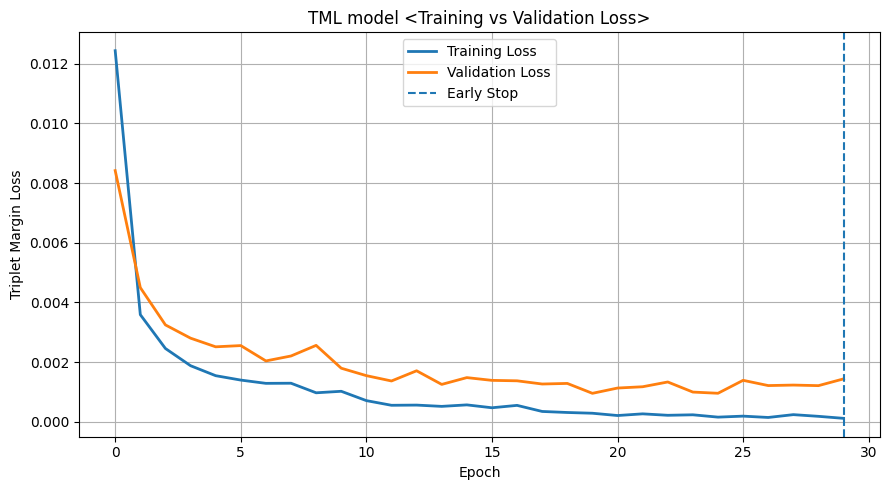

In [ ]:
import matplotlib.pyplot as plt

stop_epoch = len(train_losses)

plt.figure(figsize=(9, 5))

plt.plot(train_losses, label="Training Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)

plt.axvline(x=stop_epoch-1, linestyle="--", label="Early Stop")

plt.xlabel("Epoch")
plt.ylabel("Triplet Margin Loss")
plt.title("TML model <Training vs Validation Loss>")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn.functional as F

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = PhoneticEncoder(
    input_dim=PANPHON_DIM,
    hidden_dim=256,
    layers=2,
    proj_dim=128
)

encoder.load_state_dict(torch.load("/content/sanskrit_phonetic_TML_model.pkl", map_location=device))
encoder.to(device)
encoder.eval()

print("Model loaded successfully")


Model loaded successfully


In [ ]:
def get_embedding(word):
    """
    word: Sanskrit word (string)
    returns: torch.Tensor (embedding_dim,)
    """
    phonemes = akshara_to_phonemes(word)

    vectors = [
        phoneme_to_vec.get(p, torch.zeros(PANPHON_DIM))
        for p in phonemes
    ]

    x = torch.stack(vectors).unsqueeze(0).to(device)  # (1, seq_len, dim)
    lengths = torch.tensor([len(vectors)], device=device)

    with torch.no_grad():
        emb = encoder(x, lengths)

    return emb.squeeze(0).cpu()   # shape: (128,)


In [ ]:
def euclidean_distance(e1, e2):
    return torch.norm(e1 - e2, p=2).item()


In [ ]:
word_pairs = [
    ("माबि", "माभीभ"),
    ("इहैधि", "यहेधी"),
    ("इषुरि", "इशूरी"),
    ("उदेणी", "उधेनि"),
    ("इयमन्", "यमन्त"),
    ("नवप्", "प्राण"),
    ("कुल", "कूल"),
    ("सित", "सीता"),
    ("दिन", "दीन"),
    ("आसन", "आसन्न"),
    ("प्रवाह", "पर्वाह"),
    ("कर्म", "क्रम"),
    ("ग्रह", "गृह"),
    ("येवकं", "ऐवकं"),
    ("विश्पतिं", "विस्पंति")
]

In [ ]:
def cosine_distance(e1, e2):

    e1_norm = torch.norm(e1)
    e2_norm = torch.norm(e2)
    if e1_norm == 0 or e2_norm == 0:
        return 1.0
    cosine_sim = torch.dot(e1, e2) / (e1_norm * e2_norm)
    return (1 - cosine_sim).item()

for w1, w2 in word_pairs:
    try:
        emb1 = get_embedding(w1)
        emb2 = get_embedding(w2)

        euclidean_dist = euclidean_distance(emb1, emb2)
        cos_dist = cosine_distance(emb1, emb2)

        print(f"{w1} - {w2} | Euclidean distance: {euclidean_dist:.4f} | Cosine distance: {cos_dist:.4f}")

    except Exception as e:
        print(f"Error processing ({w1}, {w2}): {e}")

माबि - माभीभ | Euclidean distance: 3.0145 | Cosine distance: 0.0069
इहैधि - यहेधी | Euclidean distance: 34.1371 | Cosine distance: 0.7248
इषुरि - इशूरी | Euclidean distance: 1.7651 | Cosine distance: 0.0008
उदेणी - उधेनि | Euclidean distance: 5.6564 | Cosine distance: 0.0305
इयमन् - यमन्त | Euclidean distance: 33.6744 | Cosine distance: 0.6128
नवप् - प्राण | Euclidean distance: 15.6124 | Cosine distance: 0.1087
कुल - कूल | Euclidean distance: 0.9615 | Cosine distance: 0.0004
सित - सीता | Euclidean distance: 7.5866 | Cosine distance: 0.0172
दिन - दीन | Euclidean distance: 0.8187 | Cosine distance: 0.0003
आसन - आसन्न | Euclidean distance: 6.0310 | Cosine distance: 0.0118
प्रवाह - पर्वाह | Euclidean distance: 1.2137 | Cosine distance: 0.0004
कर्म - क्रम | Euclidean distance: 3.3108 | Cosine distance: 0.0043
ग्रह - गृह | Euclidean distance: 7.0280 | Cosine distance: 0.0131
येवकं - ऐवकं | Euclidean distance: 42.0009 | Cosine distance: 0.8093
विश्पतिं - विस्पंति | Euclidean distance: 3.9015 

In [ ]:
results = []

for w1, w2 in word_pairs:
    try:
        emb1 = get_embedding(w1)
        emb2 = get_embedding(w2)

        euclidean_dist = euclidean_distance(emb1, emb2)
        cos_dist = cosine_distance(emb1, emb2)

        results.append((w1, w2, euclidean_dist, cos_dist))
        print(f"{w1} - {w2} | Euclidean distance: {euclidean_dist:.4f} | Cosine distance: {cos_dist:.4f}")

    except Exception as e:
        print(f"Error processing ({w1}, {w2}): {e}")

माबि - माभीभ | Euclidean distance: 3.0145 | Cosine distance: 0.0069
इहैधि - यहेधी | Euclidean distance: 34.1371 | Cosine distance: 0.7248
इषुरि - इशूरी | Euclidean distance: 1.7651 | Cosine distance: 0.0008
उदेणी - उधेनि | Euclidean distance: 5.6564 | Cosine distance: 0.0305
इयमन् - यमन्त | Euclidean distance: 33.6744 | Cosine distance: 0.6128
नवप् - प्राण | Euclidean distance: 15.6124 | Cosine distance: 0.1087
कुल - कूल | Euclidean distance: 0.9615 | Cosine distance: 0.0004
सित - सीता | Euclidean distance: 7.5866 | Cosine distance: 0.0172
दिन - दीन | Euclidean distance: 0.8187 | Cosine distance: 0.0003
आसन - आसन्न | Euclidean distance: 6.0310 | Cosine distance: 0.0118
प्रवाह - पर्वाह | Euclidean distance: 1.2137 | Cosine distance: 0.0004
कर्म - क्रम | Euclidean distance: 3.3108 | Cosine distance: 0.0043
ग्रह - गृह | Euclidean distance: 7.0280 | Cosine distance: 0.0131
येवकं - ऐवकं | Euclidean distance: 42.0009 | Cosine distance: 0.8093
विश्पतिं - विस्पंति | Euclidean distance: 3.9015 

patience = 15 , ran for 32 epochs

माबि - माभीभ | Euclidean distance: 1.7096
इहैधि - यहेधी | Euclidean distance: 23.8212
इषुरि - इशूरी | Euclidean distance: 0.8615
उदेणी - उधेनि | Euclidean distance: 2.3987
इयमन् - यमन्त | Euclidean distance: 19.7186
नवप् - प्राण | Euclidean distance: 13.6405

Patience = 20 epoxhs = 66
माबि - माभीभ | Euclidean distance: 3.0111
इहैधि - यहेधी | Euclidean distance: 40.7203
इषुरि - इशूरी | Euclidean distance: 2.1803
उदेणी - उधेनि | Euclidean distance: 4.2947
इयमन् - यमन्त | Euclidean distance: 42.0686
नवप् - प्राण | Euclidean distance: 22.1546

patience = 9, epochs = 44, Train Loss: 0.0002 | Val Loss: 0.0007

माबि - माभीभ | Euclidean distance: 8.2003
इहैधि - यहेधी | Euclidean distance: 27.1604
इषुरि - इशूरी | Euclidean distance: 2.3026
उदेणी - उधेनि | Euclidean distance: 3.1128
इयमन् - यमन्त | Euclidean distance: 26.4312
नवप् - प्राण | Euclidean distance: 13.2765

patience = 9, epochs= 34

* माबि - माभीभ | Euclidean distance: 1.0501 | Cosine distance: 0.0014
* इहैधि - यहेधी | Euclidean distance: 20.9341 | Cosine distance: 0.9220
* इषुरि - इशूरी | Euclidean distance: 0.8332 | Cosine distance: 0.0011
* उदेणी - उधेनि | Euclidean distance: 3.7462 | Cosine distance: 0.0195
* इयमन् - यमन्त | Euclidean distance: 21.4631 | Cosine distance: 0.4308
* नवप् - प्राण | Euclidean distance: 12.6588 | Cosine distance: 0.1812



Patience = 9, epochs = 42
* माबि - माभीभ | Euclidean distance: 7.4721 | Cosine distance: 0.0476
* इहैधि - यहेधी | Euclidean distance: 26.2521 | Cosine distance: 0.7530
* इषुरि - इशूरी | Euclidean distance: 1.1191 | Cosine distance: 0.0008
* उदेणी - उधेनि | Euclidean distance: 3.0543 | Cosine distance: 0.0041
* इयमन् - यमन्त | Euclidean distance: 29.0171 | Cosine distance: 0.5585
* नवप् - प्राण | Euclidean distance: 16.4873 | Cosine distance: 0.2162

epochs = 23, patience = 10

* माबि - माभीभ | Euclidean distance: 3.1136 | Cosine distance: 0.0236
* इहैधि - यहेधी | Euclidean distance: 15.4666 | Cosine distance: 0.8752
* इषुरि - इशूरी | Euclidean distance: 0.9846 | Cosine distance: 0.0024
* उदेणी - उधेनि | Euclidean distance: 1.9541 | Cosine distance: 0.0093
* इयमन् - यमन्त | Euclidean distance: 12.6136 | Cosine distance: 0.4795
* नवप् - प्राण | Euclidean distance: 7.8839 | Cosine distance: 0.2264
* कुल - कूल | Euclidean distance: 0.6813 | Cosine distance: 0.0017
* सित - सीता | Euclidean distance: 1.0114 | Cosine distance: 0.0026
* दिन - दीन | Euclidean distance: 0.6899 | Cosine distance: 0.0008
* आसन - आसन्न | Euclidean distance: 2.3619 | Cosine distance: 0.0057
* प्रवाह - पर्वाह | Euclidean distance: 0.8863 | Cosine distance: 0.0020
* कर्म - क्रम | Euclidean distance: 2.3541 | Cosine distance: 0.0157
* ग्रह - गृह | Euclidean distance: 1.6780 | Cosine distance: 0.0090
* येवकं - ऐवकं | Euclidean distance: 14.3983 | Cosine distance: 0.6382
* विश्पतिं - विस्पंति | Euclidean distance: 1.0962 | Cosine distance: 0.0031

epochs = 25, patience = 10

* माबि - माभीभ | Euclidean distance: 4.0391 | Cosine distance: 0.0831
* इहैधि - यहेधी | Euclidean distance: 10.4578 | Cosine distance: 0.5515
* इषुरि - इशूरी | Euclidean distance: 0.6959 | Cosine distance: 0.0020
* उदेणी - उधेनि | Euclidean distance: 2.4214 | Cosine distance: 0.0122
* इयमन् - यमन्त | Euclidean distance: 9.7334 | Cosine distance: 0.3117
* नवप् - प्राण | Euclidean distance: 5.8061 | Cosine distance: 0.1952
* कुल - कूल | Euclidean distance: 1.3265 | Cosine distance: 0.0094
* सित - सीता | Euclidean distance: 2.1189 | Cosine distance: 0.0110
* दिन - दीन | Euclidean distance: 0.6893 | Cosine distance: 0.0015
* आसन - आसन्न | Euclidean distance: 3.7947 | Cosine distance: 0.0339
* प्रवाह - पर्वाह | Euclidean distance: 0.9081 | Cosine distance: 0.0036
* कर्म - क्रम | Euclidean distance: 1.6509 | Cosine distance: 0.0093
* ग्रह - गृह | Euclidean distance: 2.7379 | Cosine distance: 0.0352
* येवकं - ऐवकं | Euclidean distance: 14.7742 | Cosine distance: 0.7162
* विश्पतिं - विस्पंति | Euclidean distance: 0.8921 | Cosine distance: 0.0036

epochs = 35, patience= 10
* माबि - माभीभ | Euclidean distance: 6.6777 | Cosine distance: 0.0442
* इहैधि - यहेधी | Euclidean distance: 21.0820 | Cosine distance: 0.6463
* इषुरि - इशूरी | Euclidean distance: 1.5760 | Cosine distance: 0.0019
* उदेणी - उधेनि | Euclidean distance: 2.0706 | Cosine distance: 0.0054
* इयमन् - यमन्त | Euclidean distance: 23.0497 | Cosine distance: 0.4569
* नवप् - प्राण | Euclidean distance: 14.5437 | Cosine distance: 0.1947
* कुल - कूल | Euclidean distance: 0.8717 | Cosine distance: 0.0006
* सित - सीता | Euclidean distance: 6.7983 | Cosine distance: 0.0187
* दिन - दीन | Euclidean distance: 0.6089 | Cosine distance: 0.0003
* आसन - आसन्न | Euclidean distance: 5.9684 | Cosine distance: 0.0234
* प्रवाह - पर्वाह | Euclidean distance: 1.5192 | Cosine distance: 0.0013
* कर्म - क्रम | Euclidean distance: 3.2015 | Cosine distance: 0.0063
* ग्रह - गृह | Euclidean distance: 4.3708 | Cosine distance: 0.0120
* येवकं - ऐवकं | Euclidean distance: 33.5488 | Cosine distance: 0.7793
* विश्पतिं - विस्पंति | Euclidean distance: 6.2329 | Cosine distance: 0.0271